# 05 - Modelo Transformer manual con DistilBERT

Este notebook implementa un modelo de clasificación de sentimientos usando la siguiente secuencia:

```text
DistilBERT base
↓
embedding [CLS]
↓
Dropout
↓
nn.Linear(hidden_size, num_labels)
↓
CrossEntropyLoss
↓
training loop manual con PyTorch
```

La idea es evitar `AutoModelForSequenceClassification` y `Trainer` para entender mejor qué está pasando internamente.

Este notebook usa los archivos generados por `02_preprocessing.ipynb`:

```text
data/processed/bert_train_imdb.pt
data/processed/bert_val_imdb.pt
data/processed/bert_test_imdb.pt
data/processed/y_train_imdb.npy
data/processed/y_val_imdb.npy
data/processed/y_test_imdb.npy
```


## 1. Importar librerías

Usaremos Hugging Face solo para cargar `DistilBertModel`, es decir, el transformer base. La cabeza de clasificación y el entrenamiento los hacemos manualmente con PyTorch.


In [1]:
import os
from pathlib import Path

import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertModel, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.8.0+cu128
CUDA available: True


## 2. Configuración general



In [2]:
SEED = 42
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
DROPOUT_RATE = 0.3
MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = 2

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

EARLY_STOPPING_PATIENCE = 3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Cargar los tensores tokenizados y las etiquetas

Los archivos `.pt` contienen los tensores de BERT, normalmente `input_ids` y `attention_mask`.

Los archivos `.npy` contienen las etiquetas numéricas.


In [3]:
def load_bert_split(split_name, max_samples=None):
    bert_path = PROCESSED_DIR / f"bert_{split_name}_imdb.pt"
    labels_path = PROCESSED_DIR / f"y_{split_name}_imdb.npy"

    if not bert_path.exists():
        raise FileNotFoundError(f"BERT tensor file not found: {bert_path}")
    if not labels_path.exists():
        raise FileNotFoundError(f"Label file not found: {labels_path}")

    # ADVERTENCIA: weights_only=False permite ejecucion de codigo arbitrario.
    # Solo cargar archivos .pt generados por este mismo proyecto y de fuentes de confianza.
    encoded = torch.load(bert_path, weights_only=False)
    labels = np.load(labels_path)

    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]
    labels = torch.tensor(labels, dtype=torch.long)

    if max_samples is not None:
        input_ids = input_ids[:max_samples]
        attention_mask = attention_mask[:max_samples]
        labels = labels[:max_samples]

    return input_ids, attention_mask, labels

train_input_ids, train_attention_mask, train_labels = load_bert_split("train", MAX_TRAIN_SAMPLES)
val_input_ids, val_attention_mask, val_labels = load_bert_split("val", MAX_VAL_SAMPLES)
test_input_ids, test_attention_mask, test_labels = load_bert_split("test", MAX_TEST_SAMPLES)

print("Train input_ids:", train_input_ids.shape)
print("Val input_ids:  ", val_input_ids.shape)
print("Test input_ids: ", test_input_ids.shape)
print("Train labels:   ", train_labels.shape)
print("Unique labels:  ", torch.unique(train_labels).tolist())

Train input_ids: torch.Size([35020, 256])
Val input_ids:   torch.Size([7480, 256])
Test input_ids:  torch.Size([7500, 256])
Train labels:    torch.Size([35020])
Unique labels:   [0, 1]


## 4. Crear Dataset y DataLoader

El `Dataset` entrega cada muestra como un diccionario con:

- `input_ids`
- `attention_mask`
- `labels`


In [4]:
class SentimentDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "input_ids": self.input_ids[index],
            "attention_mask": self.attention_mask[index],
            "labels": self.labels[index]
        }

train_dataset = SentimentDataset(train_input_ids, train_attention_mask, train_labels)
val_dataset = SentimentDataset(val_input_ids, val_attention_mask, val_labels)
test_dataset = SentimentDataset(test_input_ids, test_attention_mask, test_labels)

NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 2189
Val batches:   468
Test batches:  469


## 5. Definir el modelo manual

Aquí ocurre la parte importante:

1. `DistilBertModel` genera representaciones contextuales.
2. Tomamos el primer token `[:, 0, :]`, que corresponde al embedding tipo `[CLS]`.
3. Aplicamos `Dropout`.
4. Aplicamos una capa lineal `nn.Linear(hidden_size, num_labels)`.
5. El resultado son los `logits` para cada clase.


In [5]:
class DistilBertManualClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout_rate=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate)  # evitar overfitting
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)
        logits = self.classifier(cls_embedding)
        return logits

model = DistilBertManualClassifier(
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout_rate=DROPOUT_RATE
).to(DEVICE)

print(model)
print(f"Number of labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertManualClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (li

## 6. Definir función de pérdida y optimizador

Usamos `CrossEntropyLoss` porque es clasificación multiclase. También funciona para clasificación binaria si las etiquetas son `0` y `1`, porque el modelo produce dos logits.


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")

total_training_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print(f"Total training steps: {total_training_steps}")
print(f"Warmup steps: {warmup_steps}")

Trainable parameters: 66,364,418
Total parameters:     66,364,418
Total training steps: 6567
Warmup steps: 656


## 7. Funciones de entrenamiento y evaluación

Este es el ciclo manual: `forward`, cálculo de pérdida, `backward`, actualización con el optimizador y evaluación con métricas.


In [7]:
def train_one_epoch(model, data_loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            all_predictions.extend(predictions.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_predictions
    }

## 8. Entrenar el modelo

Este entrenamiento hace fine-tuning completo porque todos los parámetros de DistilBERT tienen `requires_grad=True`.

Si quieres entrenar solo la capa lineal, puedes congelar DistilBERT antes del entrenamiento con:

```python
for param in model.bert.parameters():
    param.requires_grad = False
```


In [8]:
history = []
best_val_f1 = -1.0
best_model_path = MODELS_DIR / "transformer_distilbert_manual_classifier_best.pt"
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)

    epoch_info = {
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"]
    }

    history.append(epoch_info)

    print(f"Train loss: {train_metrics['loss']:.4f} | Train acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['f1']:.4f}")
    print(f"Val loss:   {val_metrics['loss']:.4f} | Val acc:   {val_metrics['accuracy']:.4f} | Val F1:   {val_metrics['f1']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved to: {best_model_path}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement. Patience: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered. Training stopped.")
            break


Epoch 1/3
----------------------------------------
Train loss: 0.3101 | Train acc: 0.8634 | Train F1: 0.8634
Val loss:   0.2189 | Val acc:   0.9138 | Val F1:   0.9138
Best model saved to: ../models/transformer_distilbert_manual_classifier_best.pt

Epoch 2/3
----------------------------------------
Train loss: 0.1770 | Train acc: 0.9402 | Train F1: 0.9402
Val loss:   0.2414 | Val acc:   0.9134 | Val F1:   0.9133
No improvement. Patience: 1/3

Epoch 3/3
----------------------------------------
Train loss: 0.1048 | Train acc: 0.9706 | Train F1: 0.9706
Val loss:   0.3450 | Val acc:   0.9206 | Val F1:   0.9206
Best model saved to: ../models/transformer_distilbert_manual_classifier_best.pt


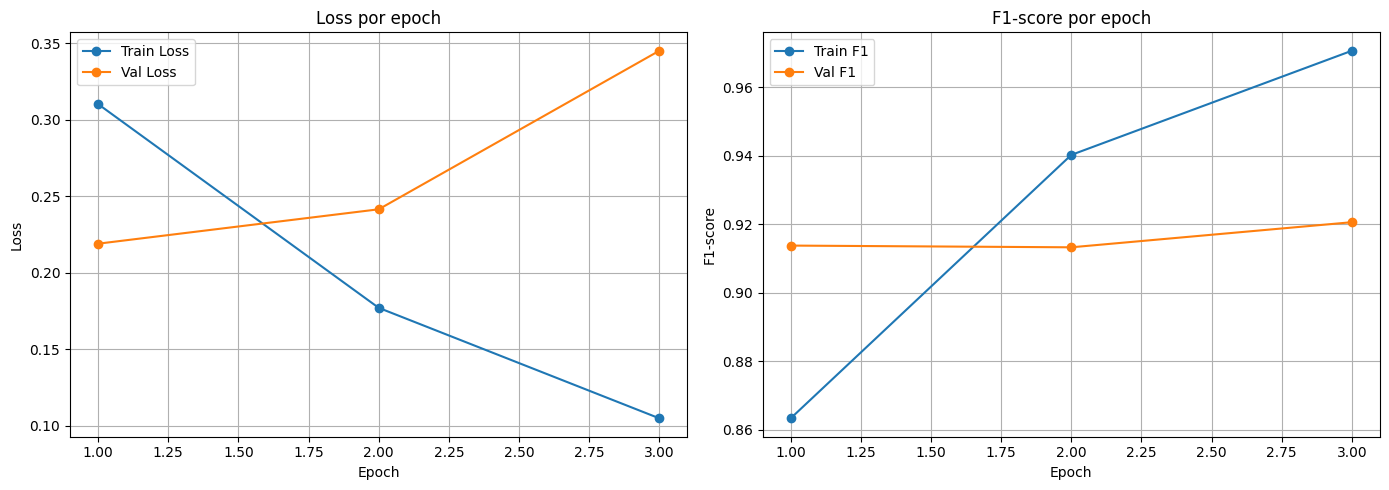

Curvas guardadas en models/training_curves.png


In [9]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = [h["epoch"] for h in history]

axes[0].plot(epochs_range, [h["train_loss"] for h in history], label="Train Loss", marker="o")
axes[0].plot(epochs_range, [h["val_loss"] for h in history], label="Val Loss", marker="o")
axes[0].set_title("Loss por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, [h["train_f1"] for h in history], label="Train F1", marker="o")
axes[1].plot(epochs_range, [h["val_f1"] for h in history], label="Val F1", marker="o")
axes[1].set_title("F1-score por epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(MODELS_DIR / "transformer_training_curves.png", dpi=150)
plt.show()
print("Curvas guardadas en models/training_curves.png")

## 9. Evaluación final en test

El conjunto de test solo debe usarse al final, después de tomar decisiones con validación.


In [10]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.to(DEVICE)

test_metrics = evaluate(model, test_loader, criterion, DEVICE)

print("Test results")
print("=" * 40)
print(f"Loss:      {test_metrics['loss']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-score:  {test_metrics['f1']:.4f}")

Test results
Loss:      0.3470
Accuracy:  0.9153
Precision: 0.9155
Recall:    0.9153
F1-score:  0.9153


## 10. Reporte de clasificación y matriz de confusión

Esto permite revisar si el modelo se equivoca más en una clase que en otra.


In [11]:
print("Classification report:")
print(classification_report(test_metrics["labels"], test_metrics["predictions"], zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(test_metrics["labels"], test_metrics["predictions"]))

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      3750
           1       0.91      0.92      0.92      3750

    accuracy                           0.92      7500
   macro avg       0.92      0.92      0.92      7500
weighted avg       0.92      0.92      0.92      7500

Confusion matrix:
[[3398  352]
 [ 283 3467]]


## 11. Guardar el modelo final

Guardamos los pesos entrenados y algunos metadatos básicos para poder cargar el modelo después.


In [12]:
final_model_path = MODELS_DIR / "transformer_distilbert_manual_classifier_final.pt"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "num_labels": NUM_LABELS,
    "dropout_rate": DROPOUT_RATE,
    "history": history
}

torch.save(checkpoint, final_model_path)
print(f"Final checkpoint saved to: {final_model_path}")

Final checkpoint saved to: ../models/transformer_distilbert_manual_classifier_final.pt


## 12. Cargar el modelo para inferencia

Este bloque muestra cómo reconstruir el modelo y cargar los pesos guardados.


In [13]:
# ADVERTENCIA: weights_only=False permite ejecucion de codigo arbitrario.
# Solo cargar archivos .pt generados por este mismo proyecto y de fuentes de confianza.
checkpoint = torch.load(
    final_model_path,
    map_location=DEVICE,
    weights_only=False
)

loaded_model = DistilBertManualClassifier(
    model_name=checkpoint["model_name"],
    num_labels=checkpoint["num_labels"],
    dropout_rate=checkpoint["dropout_rate"]
).to(DEVICE)

loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Model loaded correctly for inference.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded correctly for inference.


## Conclusión

Este notebook sí implementa fine-tuning manual porque:

- carga `DistilBertModel`, no `AutoModelForSequenceClassification`;
- construye explícitamente `Dropout` y `nn.Linear`;
- usa `CrossEntropyLoss` directamente;
- ejecuta el ciclo de entrenamiento manual con PyTorch;
- actualiza los pesos de DistilBERT y de la capa clasificadora.

Esto permite explicar mucho mejor la arquitectura en la sustentación.
